In [110]:

# current paths are the exact files given by Anna due to root access structure on lab PC,
# I'll rewrite the code to use direct server paths
import traces as t
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.linalg import norm
from scipy.interpolate import griddata
from scipy.interpolate import interpn
from scipy import interpolate
from numba import jit, cuda,prange



@jit(target_backend='cuda')
def mm(A,B,C):
    s = float(0)
    for i in prange(560*560):
        AA = A[i,:]
        #C[i,:] = np.dot(AA,B)
        c = np.dot(AA,B)
        C[i, :] = c
        s = s + c**2
        #C[i, :] = int(np.dot(A[i, :], B))
    s = np.sqrt(s)

    for i in prange(560*560):
        C[i,:] = C[i,:]/s*10000
    return C

@jit(target_backend='cuda')
def pix(im,x,y,k):
    p=0
    for i in prange(k):
        for j in prange(k):
            p = p + im[x+i-int(k/2),y+j-int(k/2)]
    return p

pathAB32 = '/run/user/1001/gvfs/smb-share:server=sahale.biostr.washington.edu,share=data/Subjects/AB_0032/2024-03-14/1'
pathAL14 = '/run/user/1001/gvfs/smb-share:server=sahale.biostr.washington.edu,share=data/Subjects/AL_0014/2022-08-15/1'

path = pathAL14

#input = np.load(path + '/lightCommand.raw.npy')
#print(input.shape)

#t_stamps = np.load(path + '/lightCommand.timestamps_Timeline.npy')
#print(t_stamps)




temp  = np.load(path + '/corr/svdTemporalComponents_corr.npy').T
print("dynamics shape")
print(temp.shape)

spat  = np.load(path + '/blue/svdSpatialComponents.npy')
print("Spatial shape")
print(spat.shape)

face_proc = np.load(path + '/face_proc.npy', allow_pickle=True).item()
yrange = face_proc['rois'][0]['yrange_bin']
xrange = face_proc['rois'][0]['xrange_bin']
mean = face_proc['avgframe'][0]

motTemp = face_proc['motSVD'][1]
motSpat = face_proc['motMask_reshape'][1]

print(motSpat.shape)
print(motTemp.shape)

print(mean.shape)

print(xrange.shape)
print(yrange.shape)

 



dynamics shape
(500, 115379)
Spatial shape
(560, 560, 2000)
(122, 116, 500)
(230746, 500)
(21312,)
(116,)
(122,)


(313600, 100)


/tmp/ipykernel_497836/467957083.py:13: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because Function "mm" failed type inference due to: No implementation of function Function(<function dot at 0x792ca12d1360>) found for signature:
 
 >>> dot(array(float64, 1d, C), array(float32, 1d, A))
 
There are 4 candidate implementations:
      - Of which 4 did not match due to:
      Overload in function '_OverloadWrapper._build.<locals>.ol_generated': File: numba/core/overload_glue.py: Line 129.
        With argument(s): '(array(float64, 1d, C), array(float32, 1d, A))':
       Rejected as the implementation raised a specific error:
         TypingError: np.dot() arguments must all have the same dtype
  raised from /home/mist/Documents/projects/Brain/code/.venv/lib/python3.10/site-packages/numba/core/typing/npydecl.py:915

During: resolving callee type: Function(<function dot at 0x792ca12d1360>)
During: typing of call at /tmp/ipykernel_497836/467957083.py (19)

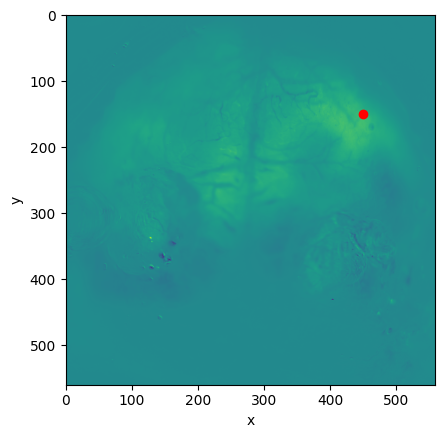

In [111]:

# reconstruct image and pixelate
n=100
U=np.zeros((560*560,0),int)
for i in range(n):
    U=np.column_stack([U,spat[:,:,i].flatten()])


print(U.shape)

t = 1000
Vi = temp[:n,t]

C = np.zeros((560 * 560, 1))

cc = mm(U,Vi,C)
# im = cc.astype(int)
ims = cc.reshape(560,560)


#x = 205
#y = 305
x = 450
y = 150

plt.imshow(ims)
plt.plot(x,y,'ro')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


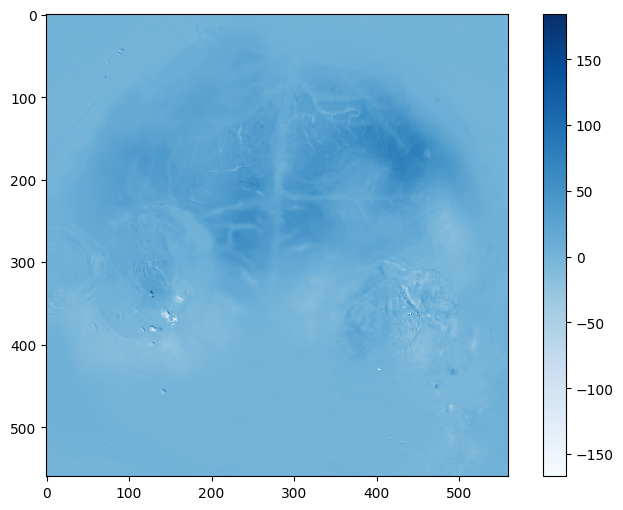

In [112]:
p=0
k=4
# for i in range(k):
#     for j in range(k):
#         p = p + ims[x+i-int(k/2),y+j-int(k/2)]
#         # print(ims[x+i-k/2,y+j-k/2])

p = pix(ims,x,y,k)



fig, ax = plt.subplots(figsize=(9, 6))
pos = ax.imshow(ims, cmap='Blues', interpolation='none')
fig.colorbar(pos, ax=ax)
plt.show()

In [113]:
# Pixel value for entire dataset:
N = 1000
T0 = 20000


x1 = 205
y1 = 305
x2 = 450
y2 = 150
# N = temp.shape[1]
# T0 = 0
pt1 = np.zeros((N,1))
for s in range(N):
    Vi = temp[:n,T0+s]

    # get image
    C = np.zeros((560 * 560, 1))

    cc = mm(U,Vi,C)
    # im = cc.astype(int)
    imsi = cc.reshape(560,560)

    # get pixels kernel average
    p = 0
    k = 4
    # for i in range(k):
    #     for j in range(k):
    #         p = p + imsi[x+i-int(k/2),y+j-int(k/2)]/(k**2)
    #         #print(ims[x+i-k/2,y+j-k/2])
    p = pix(imsi,x1,y1,k)
    print(s)

    pt1[s] = p

pt2 = np.zeros((N,1))
for s in range(N):
    Vi = temp[:n,T0+s]

    # get image
    C = np.zeros((560 * 560, 1))

    cc = mm(U,Vi,C)
    # im = cc.astype(int)
    imsi = cc.reshape(560,560)

    # get pixels kernel average
    p = 0
    k = 4
    # for i in range(k):
    #     for j in range(k):
    #         p = p + imsi[x+i-int(k/2),y+j-int(k/2)]/(k**2)
    #         #print(ims[x+i-k/2,y+j-k/2])
    p = pix(imsi,x2,y2,k)
    print(s)

    pt2[s] = p

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [114]:
print(temp.shape[1])

115379


[[-704.4387391 ]
 [-648.42276167]
 [-523.03673393]
 [-352.63882735]
 [-127.70428712]
 [ 101.9321332 ]
 [ 216.82593935]
 [ 335.09506942]
 [ 428.19778786]
 [ 501.33997067]
 [ 603.41259508]
 [ 551.84395211]
 [ 284.07877355]
 [-112.91239272]
 [-400.3739319 ]
 [-185.31431136]
 [ 278.39980367]
 [ 802.86847775]
 [ 921.46563901]
 [ 884.98233042]
 [ 941.89560149]
 [ 922.03403553]
 [ 924.3070223 ]
 [ 895.48813236]
 [ 895.8022499 ]
 [ 909.41299522]
 [ 869.41734874]
 [ 890.0601629 ]
 [ 862.16166048]
 [ 876.16612253]
 [ 818.54478551]
 [ 807.8921012 ]
 [ 805.69888157]
 [ 784.84370519]
 [ 759.70506823]
 [ 728.18121272]
 [ 708.08482308]
 [ 650.14564073]
 [ 525.61091822]
 [ 402.5097926 ]
 [ 362.44517474]
 [ 420.24170649]
 [ 508.15094759]
 [ 545.14498351]
 [ 581.3851882 ]
 [ 625.60040371]
 [ 651.60474007]
 [ 672.10155876]
 [ 638.78471783]
 [ 706.10248995]
 [ 690.35716663]
 [ 675.65433306]
 [ 614.52518673]
 [ 578.9889213 ]
 [ 563.42434431]
 [ 420.83340555]
 [ 257.12706363]
 [ 236.91625126]
 [ 146.3765704

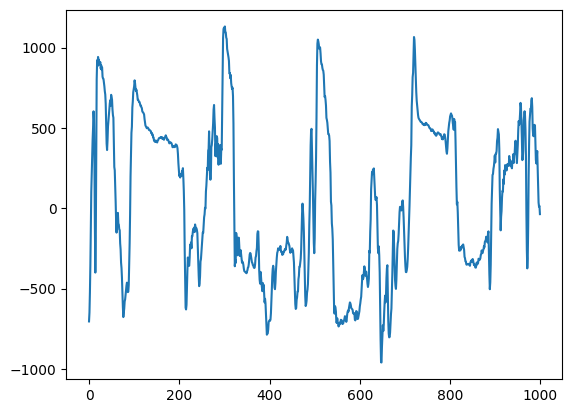

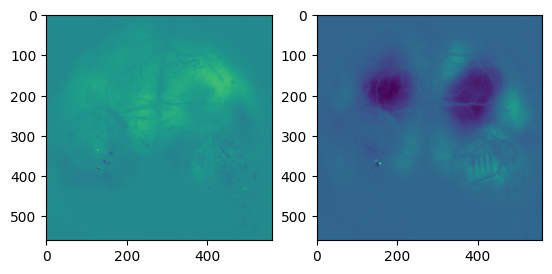

In [115]:
print(pt1)

plt.plot(pt1)
plt.show()



f, axarr = plt.subplots(1,2)
axarr[0].imshow(ims)
axarr[1].imshow(imsi)
plt.show()


dict_keys(['filenames', 'save_path', 'Ly', 'Lx', 'sbin', 'fullSVD', 'save_mat', 'Lybin', 'Lxbin', 'sybin', 'sxbin', 'LYbin', 'LXbin', 'avgframe', 'avgmotion', 'avgframe_reshape', 'avgmotion_reshape', 'motion', 'motSVD', 'motMask', 'motMask_reshape', 'pupil', 'running', 'blink', 'rois', 'sy', 'sx'])
(115373, 10)
[ 94.42582   91.62415  100.62567  ... 117.353775 214.61969  205.28313 ]


(115373,)


<function matplotlib.pyplot.show(close=None, block=None)>

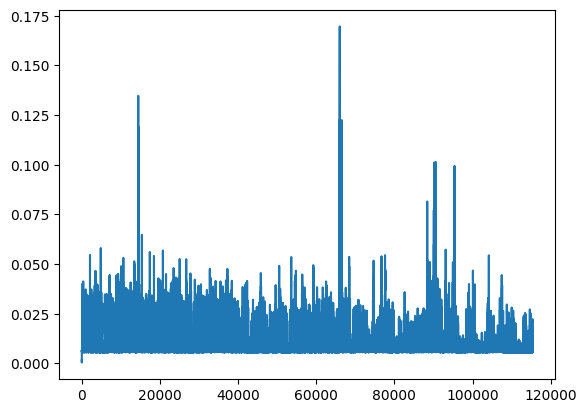

In [116]:
r=10  
motTempr = motTemp[::2,:r]


motTempf = motTemp[::2,:]


motion = face_proc['motion'][1]
motions = motion[::2]

avg_motion = np.array(face_proc['avgmotion'])
print(face_proc.keys())

# print(avg_motion)

# print(motion.shape)
# print(temp.shape)
print(motTempr.shape)

plt.plot(motTempr[0:1000,1])
plt.show
plt.close()
# plt.plot(motTempr)
# plt.show
# print(avg_motion)
# print(avg_motion.shape)
print(np.linalg.norm(motTempr,2,1))
motTempn = np.divide(motTempr.T,np.linalg.norm(motTempr,2,1)).T
motTempfn = np.divide(motTempf.T,np.linalg.norm(motTempf,2,1)).T


plt.plot(motTempn[0:1000,1])
plt.show
plt.close()
print(motions.shape)


plt.plot(motions/1e6)
plt.show

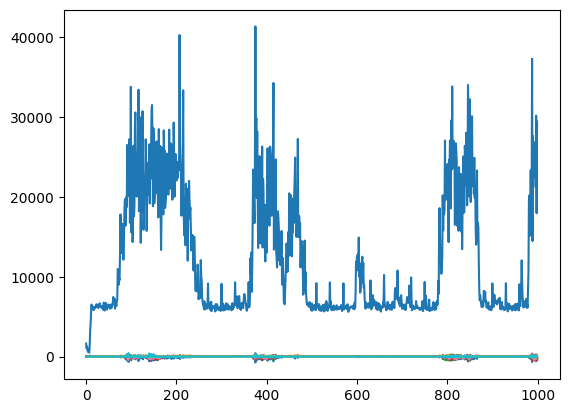

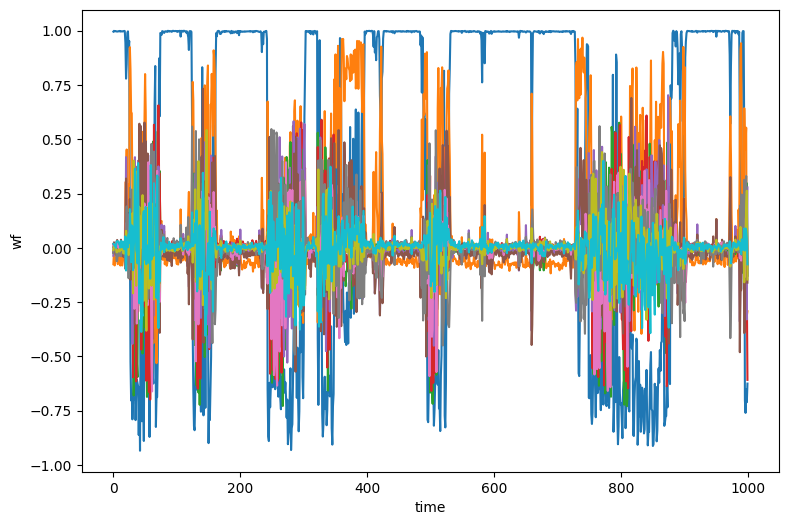

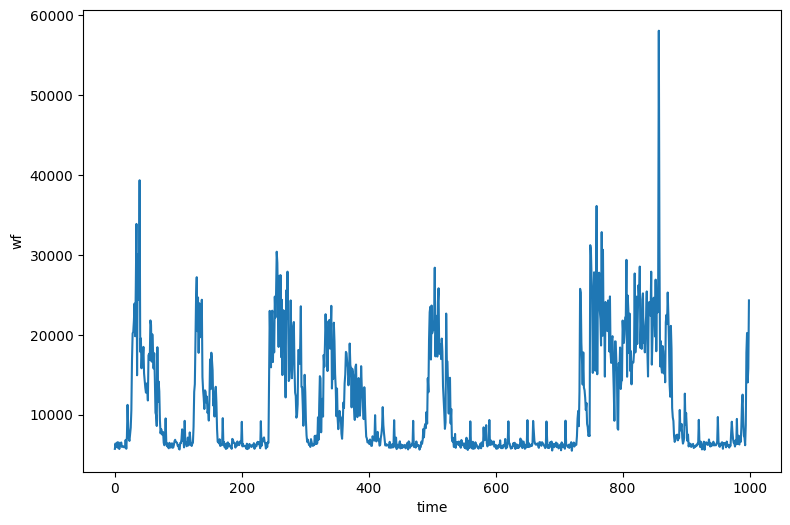

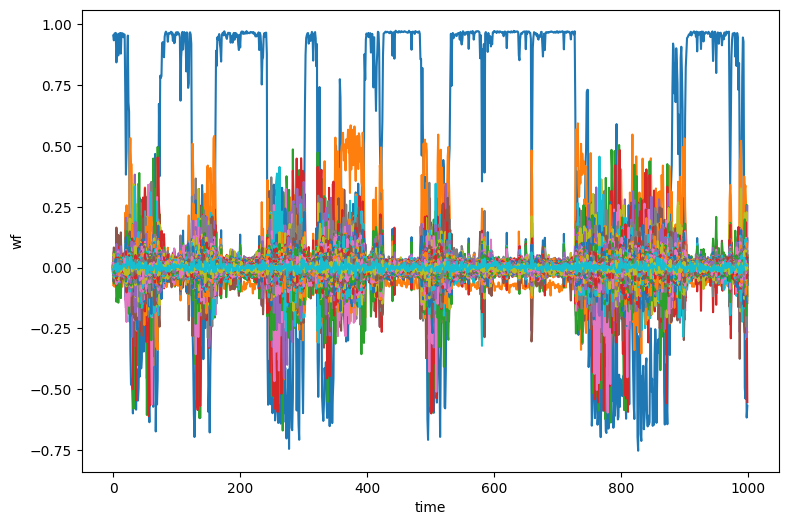

In [117]:
plt.plot(motTempr[:1000,:])
plt.show

plt.plot(motions[:1000])
plt.show


fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(motTempn[4000:5000,:])
ax.set(xlabel='time',ylabel = 'wf')
#ax.vlines(x = laser_on[:res],ymin = -0.02, ymax = 0.02, color = 'k', label = 'input')
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(motions[4000:5000])
ax.set(xlabel='time',ylabel = 'wf')
#ax.vlines(x = laser_on[:res],ymin = -0.02, ymax = 0.02, color = 'k', label = 'input')
plt.show()


fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(motTempfn[4000:5000,:])
ax.set(xlabel='time',ylabel = 'wf')
#ax.vlines(x = laser_on[:res],ymin = -0.02, ymax = 0.02, color = 'k', label = 'input')
plt.show()





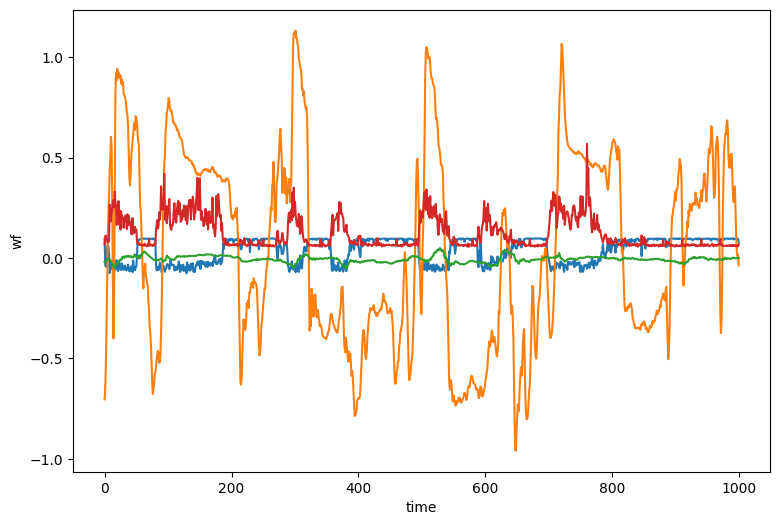

In [123]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(motTempfn[T0:T0+N,0]/10)
ax.plot(pt1/1e3)
ax.plot(pt2/1e3)
ax.plot(motions[T0:T0+N]/1e5)
ax.set(xlabel='time',ylabel = 'wf')
#ax.vlines(x = laser_on[:res],ymin = -0.02, ymax = 0.02, color = 'k', label = 'input')
plt.show()

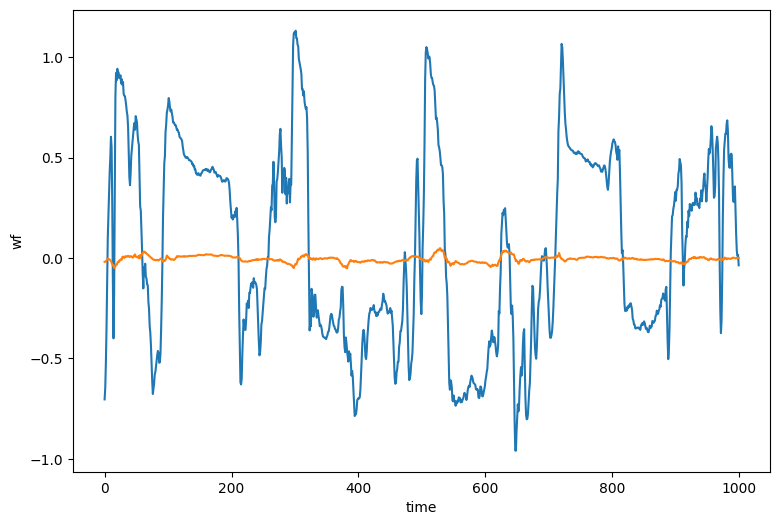

In [125]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(pt1/1e3)
ax.plot(pt2/1e3)
ax.set(xlabel='time',ylabel = 'wf')
#ax.vlines(x = laser_on[:res],ymin = -0.02, ymax = 0.02, color = 'k', label = 'input')
plt.show()
plt.close()

/home/mist/Documents/projects/Brain/code/.venv/lib/python3.10/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 256 is greater than input length  = 1, using nperseg = 1
  warnings.warn('nperseg = {0:d} is greater than input length '


ValueError: too many values to unpack (expected 2)

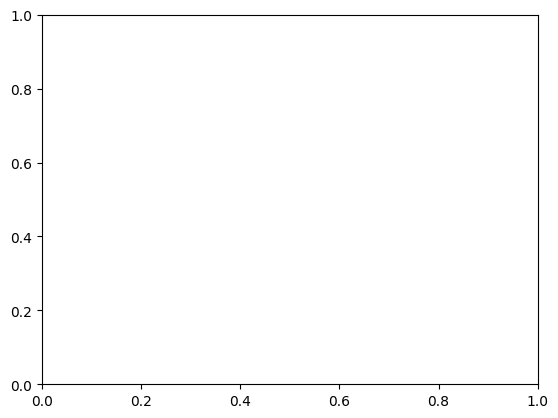

In [126]:
from scipy import signal

from scipy.fft import fftshift

fs=35

f, t, Sxx = signal.spectrogram(pt1, fs)

plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [120]:
np.save(path + '/pixelated.npy', pt) # save

/home/mist/Documents/projects/Brain/code/.venv/lib/python3.10/site-packages/matplotlib/axes/_axes.py:7726: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


TypeError: Invalid shape (129, 256, 6) for image data

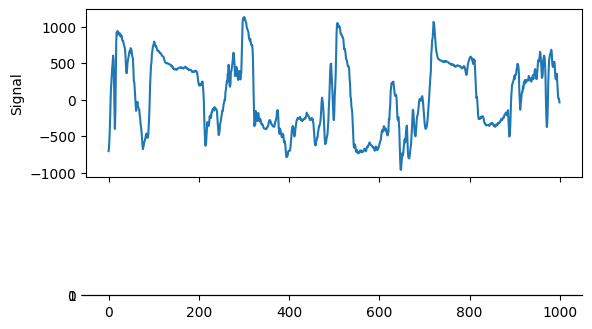

In [140]:
NFFT = 256  # the length of the windowing segments
Fs = 35  # the sampling frequency

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
ax1.plot(pt1)
ax1.set_ylabel('Signal')

Pxx, freqs, bins, im = ax2.specgram(pt1, NFFT=NFFT, Fs=Fs)
# The `specgram` method returns 4 objects. They are:
# - Pxx: the periodogram
# - freqs: the frequency vector
# - bins: the centers of the time bins
# - im: the .image.AxesImage instance representing the data in the plot
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')

plt.show()

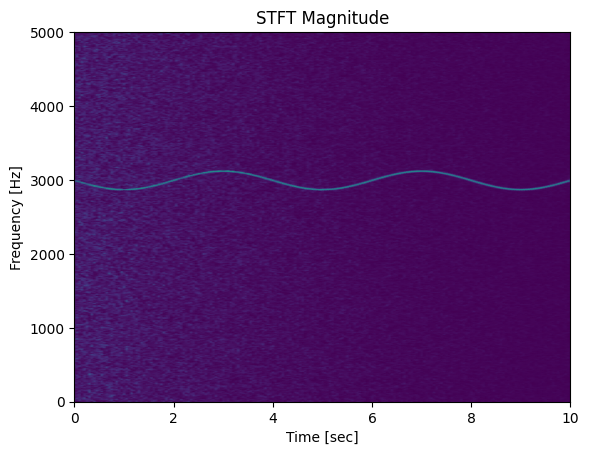

In [139]:
from scipy import signal
rng = np.random.default_rng()
fs = 10e3
N = 1e5
amp = 2 * np.sqrt(2)
noise_power = 0.01 * fs / 2
time = np.arange(N) / float(fs)
mod = 500*np.cos(2*np.pi*0.25*time)
carrier = amp * np.sin(2*np.pi*3e3*time + mod)
noise = rng.normal(scale=np.sqrt(noise_power),

                   size=time.shape)

noise *= np.exp(-time/5)

x = carrier + noise

f, t, Zxx = signal.stft(x, fs, nperseg=1000)

plt.pcolormesh(t, f, np.abs(Zxx), vmin=0, vmax=amp, shading='gouraud')

plt.title('STFT Magnitude')

plt.ylabel('Frequency [Hz]')

plt.xlabel('Time [sec]')

plt.show()

/home/mist/Documents/projects/Brain/code/.venv/lib/python3.10/site-packages/scipy/signal/spectral.py:1964: UserWarning: nperseg = 1000 is greater than input length  = 1, using nperseg = 1
  warnings.warn('nperseg = {0:d} is greater than input length '


ValueError: too many values to unpack (expected 2)

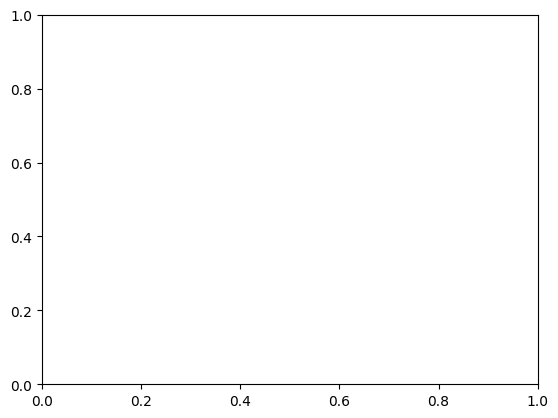

In [145]:
from scipy import signal
rng = np.random.default_rng()
fs = 35
N = 1000


f, t, Zxx = signal.stft(pt1, fs, nperseg=1000)

plt.pcolormesh(t, f, np.abs(Zxx), vmin=0, vmax=1, shading='gouraud')

plt.title('STFT Magnitude')

plt.ylabel('Frequency [Hz]')

plt.xlabel('Time [sec]')

plt.show()